# 한국주식 호가 조회와 시세 분석

`Function/KoreanStockQuotes.py`에 만든 한국투자증권 Open API 함수를 실행하고, 현재 호가와 과거 일별 시세를 분석합니다.

In [52]:
import importlib
import os
import sys
from datetime import datetime, timedelta
from pathlib import Path

import FinanceDataReader as fdr
import pandas as pd
import requests

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from Function import KoreanStockQuotes as korean_stock_quotes

korean_stock_quotes = importlib.reload(korean_stock_quotes)
KoreanStockQuoteClient = korean_stock_quotes.KoreanStockQuoteClient
get_domestic_stock_list = korean_stock_quotes.get_domestic_stock_list
analyze_moving_averages = korean_stock_quotes.analyze_moving_averages
analyze_technical_indicators = korean_stock_quotes.analyze_technical_indicators


env_path = project_root / ".env"
if env_path.exists():
    for line in env_path.read_text(encoding="utf-8").splitlines():
        if line.strip() and not line.lstrip().startswith("#") and "=" in line:
            name, value = line.split("=", 1)
            os.environ.setdefault(name.strip(), value.strip())

stock_code = "005930"  # 삼성전자
end_date = datetime.now()
start_date = end_date - timedelta(days=365)
start_date = start_date.strftime("%Y%m%d")
end_date = end_date.strftime("%Y%m%d")

has_kis_credentials = bool(
    os.getenv("KIS_APP_KEY") and os.getenv("KIS_APP_SECRET")
)

print(f"프로젝트 경로: {project_root}")
print(f"종목코드: {stock_code}")
print(f"조회기간: {start_date} ~ {end_date}")
print(f"KIS 인증정보 확인: {'완료' if has_kis_credentials else '없음'}")

프로젝트 경로: c:\Python\3.Equity
종목코드: 005930
조회기간: 20250912 ~ 20260912
KIS 인증정보 확인: 완료


In [40]:
domestic_stock_list = get_domestic_stock_list()
print(f"국내 종목 수: {len(domestic_stock_list):,}개")
display(domestic_stock_list.groupby("시장").size().rename("종목 수").to_frame())
display(domestic_stock_list.head())

국내 종목 수: 2,873개


,종목 수
시장,
KONEX,108
KOSDAQ,1772
KOSDAQ GLOBAL,50
KOSPI,943


,종목코드,종목명,시장
0,000020,동화약품,KOSPI
1,000040,KR모터스,KOSPI
2,000050,경방,KOSPI
3,000070,삼양홀딩스,KOSPI
4,000080,하이트진로,KOSPI


## 인증 설정

다음 두 가지 방법 중 하나로 KIS 인증정보를 준비합니다.

1. `KIS_APP_KEY`, `KIS_APP_SECRET` 환경변수를 설정합니다.
2. 환경변수가 없으면 아래 Python 셀에서 보안 입력창이 표시됩니다.

입력한 키는 노트북 파일에 저장하지 않으며 화면에도 출력하지 않습니다. 과거 시점의 호가창 스냅샷은 표준 API에서 제공되지 않으므로, 과거 데이터는 일별 OHLCV로 조회합니다.

In [46]:
try:
    client = KoreanStockQuoteClient()
    print("KIS 클라이언트가 준비되었습니다.")
except ValueError:
    client = None
    print("KIS 인증정보가 없어 조회를 건너뜁니다.")

KIS 클라이언트가 준비되었습니다.


## 현재 호가

현재 매도·매수 10단 호가와 각 호가의 잔량을 조회합니다. 장중이 아니면 마지막 체결 기준 정보가 반환될 수 있습니다.

In [42]:
if client is not None:
    current_order_book = client.get_current_order_book(stock_code)
    display(current_order_book)
else:
    current_order_book = pd.DataFrame()
    print("인증정보가 없어 현재 호가를 조회하지 않았습니다.")

,호가단계,매도호가,매도잔량,매수호가,매수잔량
0,1,260000,101111,259500,31936
1,2,260500,15092,259000,255896
2,3,261000,42193,258500,297049
3,4,261500,45981,258000,284076
4,5,262000,63051,257500,330917
5,6,262500,34739,257000,400454
6,7,263000,38423,256500,179449
7,8,263500,23117,256000,210709
8,9,264000,32384,255500,158550
9,10,264500,28770,255000,327392


In [43]:
if client is not None:
    realtime_order_books = []
    for realtime_order_book in client.stream_order_book(
        stock_code,
        max_updates=1,
        idle_timeout=5,
    ):
        realtime_order_books.append(realtime_order_book)
        display(realtime_order_book)
    if not realtime_order_books:
        print("5초 동안 새로운 호가가 없어 구독을 종료했습니다.")
else:
    realtime_order_books = []
    print("인증정보가 없어 실시간 호가를 구독하지 않았습니다.")

5초 동안 새로운 호가가 없어 구독을 종료했습니다.


## 과거 일별 시세

지정 기간의 시가·고가·저가·종가·거래량·거래대금을 조회합니다. 긴 기간은 함수가 API 페이지 단위로 자동 수집합니다.

In [48]:
if client is not None:
    try:
        historical_prices = client.get_historical_prices(
            stock_code=stock_code,
            start_date=start_date,
            end_date=end_date,
        )
    except (requests.RequestException, RuntimeError) as error:
        status_code = getattr(getattr(error, "response", None), "status_code", "KIS 오류")
        print(f"KIS 일별 시세 조회 실패({status_code}); 공개 데이터로 전환합니다.")
        fallback_prices = fdr.DataReader(stock_code, start_date, end_date)
        historical_prices = (
            fallback_prices.reset_index()
            .rename(
                columns={
                    "Date": "일자",
                    "Open": "시가",
                    "High": "고가",
                    "Low": "저가",
                    "Close": "종가",
                    "Volume": "거래량",
                }
            )
            .assign(거래대금=pd.NA)
        )
    display(historical_prices.head())
    print(f"조회 건수: {len(historical_prices):,}건")
else:
    historical_prices = pd.DataFrame()
    print("인증정보가 없어 과거 시세를 조회하지 않았습니다.")

KIS 일별 시세 조회 실패(500); 공개 데이터로 전환합니다.


,일자,시가,고가,저가,종가,거래량,Change,거래대금
0,2025-09-12,74600,75600,74200,75400,28219678,0.027248,<NA>
1,2025-09-15,77200,77600,75900,76500,19908805,0.014589,<NA>
2,2025-09-16,76900,79500,76700,79400,28218265,0.037908,<NA>
3,2025-09-17,79100,79100,77100,78200,20856317,-0.015113,<NA>
4,2025-09-18,79100,80500,78600,80500,25619035,0.029412,<NA>


조회 건수: 243건


In [49]:
if not historical_prices.empty:
    moving_average_analysis = analyze_moving_averages(
        historical_prices,
        short_window=20,
        long_window=60,
    )
    display(
        moving_average_analysis[
            ["일자", "종가", "단기이동평균", "장기이동평균", "추세", "신호"]
        ].tail()
    )
    display(moving_average_analysis[moving_average_analysis["신호"] != ""])
else:
    moving_average_analysis = pd.DataFrame()
    print("분석할 과거 시세가 없습니다.")

,일자,종가,단기이동평균,장기이동평균,추세,신호
238,2026-09-07,270000,259075.0,277408.333333,하락,
239,2026-09-08,269500,261050.0,276525.000000,하락,
240,2026-09-09,269500,262550.0,275400.000000,하락,
241,2026-09-10,269000,263225.0,274166.666667,하락,
242,2026-09-11,259500,262800.0,272716.666667,하락,


,일자,시가,고가,저가,종가,거래량,Change,거래대금,단기이동평균,장기이동평균,추세,신호
206,2026-07-22,276000,276000,260000,260500,22292003,0.005792,<NA>,293775.0,294183.333333,하락,데드크로스


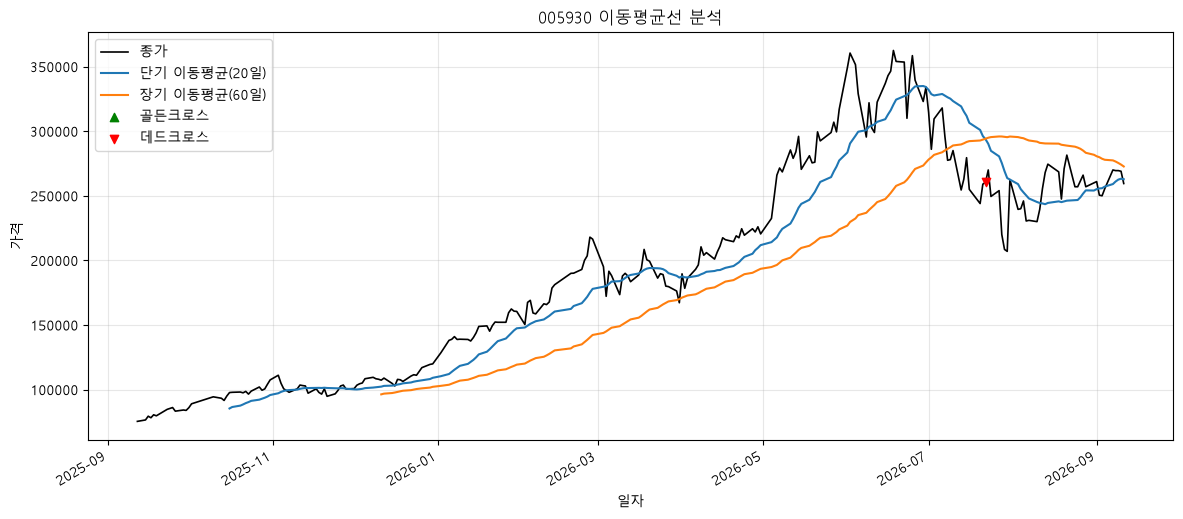

In [50]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
korean_font = next(
    (
        font_name
        for font_name in ("Malgun Gothic", "NanumGothic", "AppleGothic")
        if font_name in available_fonts
    ),
    "DejaVu Sans",
)
plt.rcParams["font.family"] = korean_font
plt.rcParams["axes.unicode_minus"] = False

if not moving_average_analysis.empty:
    figure, axis = plt.subplots(figsize=(14, 6))
    axis.plot(
        moving_average_analysis["일자"],
        moving_average_analysis["종가"],
        label="종가",
        color="black",
        linewidth=1.2,
    )
    axis.plot(
        moving_average_analysis["일자"],
        moving_average_analysis["단기이동평균"],
        label="단기 이동평균(20일)",
        color="tab:blue",
    )
    axis.plot(
        moving_average_analysis["일자"],
        moving_average_analysis["장기이동평균"],
        label="장기 이동평균(60일)",
        color="tab:orange",
    )

    golden_crosses = moving_average_analysis[
        moving_average_analysis["신호"] == "골든크로스"
    ]
    dead_crosses = moving_average_analysis[
        moving_average_analysis["신호"] == "데드크로스"
    ]
    axis.scatter(
        golden_crosses["일자"],
        golden_crosses["종가"],
        marker="^",
        color="green",
        label="골든크로스",
        zorder=3,
    )
    axis.scatter(
        dead_crosses["일자"],
        dead_crosses["종가"],
        marker="v",
        color="red",
        label="데드크로스",
        zorder=3,
    )
    axis.set_title(f"{stock_code} 이동평균선 분석")
    axis.set_xlabel("일자")
    axis.set_ylabel("가격")
    axis.grid(True, alpha=0.3)
    axis.legend()
    figure.autofmt_xdate()
    plt.show()

    if moving_average_analysis["장기이동평균"].notna().sum() == 0:
        print("장기 이동평균선은 60일 이상의 시세 데이터가 있어야 표시됩니다.")
else:
    print("분석할 과거 시세가 없습니다.")

## 간단한 분석

조회된 종가로 기간 수익률, 연환산 변동성, 최대 낙폭을 계산합니다.

In [ ]:
if not historical_prices.empty:
    prices = historical_prices.sort_values("일자").copy()
    prices["일별수익률"] = prices["종가"].pct_change()
    prices["누적수익률"] = prices["종가"] / prices["종가"].iloc[0] - 1
    prices["고점"] = prices["종가"].cummax()
    prices["낙폭"] = prices["종가"] / prices["고점"] - 1

    period_return = prices["누적수익률"].iloc[-1]
    annualized_volatility = prices["일별수익률"].std() * (252 ** 0.5)
    maximum_drawdown = prices["낙폭"].min()

    summary = pd.Series(
        {
            "기간 수익률": period_return,
            "연환산 변동성": annualized_volatility,
            "최대 낙폭": maximum_drawdown,
        }
    )
    display(summary.to_frame("값"))
    display(prices[["일자", "종가", "일별수익률", "누적수익률", "낙폭"]].tail())
else:
    print("분석할 과거 시세가 없습니다.")

,값
기간 수익률,-0.011429
연환산 변동성,0.701051
최대 낙폭,-0.123810


,일자,종가,일별수익률,누적수익률,낙폭
25,2026-09-07,270000,0.056751,0.028571,-0.040853
26,2026-09-08,269500,-0.001852,0.026667,-0.042629
27,2026-09-09,269500,0.000000,0.026667,-0.042629
28,2026-09-10,269000,-0.001855,0.024762,-0.044405
29,2026-09-11,259500,-0.035316,-0.011429,-0.078153


## 강한 매수 신호 백테스트

2026년 1월 2일부터 2026년 9월 11일까지 다음 규칙으로 백테스트합니다.

- 현재 공개 종목 목록의 시가총액 상위 500개를 분석합니다. 과거 상장폐지 종목은 포함되지 않아 생존편향이 있습니다.
- 현재 노트북과 동일하게 20일·60일 이동평균, RSI, MACD, 볼린저 밴드, 거래량을 사용합니다.
- 매 거래일 매도조건수가 1개 이상인 보유 종목은 해당일 종가로 전량 매도합니다.
- 매도 후 당일 강한 매수 신호 중 종합 점수가 가장 높은 종목 1개를 1,000,000원만큼 매수합니다.
- 총 매수 원금은 10,000,000원을 초과하지 않습니다.
- 수수료, 세금, 슬리피지는 제외하고 종가 체결을 가정합니다.
- 결과는 투자원금 대비 최종 평가금액의 수익률입니다.


```
백테스트 실행 셀은 아래 셀입니다. 실행 전 규칙과 데이터 범위를 확인하세요.
```

BACKTEST SUMMARY


,값
총 매수원금,9.999993e+08
총 매도 실현손익,2.141874e+07
최종 보유종목 평가손익,0.000000e+00
최종 수익금,2.141874e+07
투자수익률,2.141875e-02
최종 평가금액,1.021418e+09
현금잔액,1.021418e+09
매수 횟수,1.020000e+02
매도 횟수,1.010000e+02



FINAL HOLDINGS


""



TRADE LOG


,일자,구분,종목코드,종목명,수량,가격,금액,사유,매입원가,실현손익
0,2025-02-04,매수,019210,와이지-원,1893,5280.0,9995040.0,강한 매수 신호 최고점수,NaN,NaN
1,2025-02-05,매도,019210,와이지-원,1893,5390.0,10203270.0,매도조건수 2개 이상,9995040.0,208230.0
2,2025-02-05,매수,012630,HDC,782,12780.0,9993960.0,강한 매수 신호 최고점수,NaN,NaN
3,2025-02-06,매도,012630,HDC,782,13210.0,10330220.0,매도조건수 2개 이상,9993960.0,336260.0
4,2025-02-06,매수,034220,LG디스플레이,1033,9680.0,9999440.0,강한 매수 신호 최고점수,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
198,2025-07-25,매도,00088K,한화3우B,278,41783.0,11615674.0,매도조건수 2개 이상,9964354.0,1651320.0
199,2025-07-30,매도,088980,맥쿼리인프라,868,11590.0,10060120.0,매도조건수 2개 이상,9999360.0,60760.0
200,2025-08-01,매도,192400,쿠쿠홀딩스,298,28950.0,8627100.0,매도조건수 2개 이상,9983000.0,-1355900.0
201,2025-08-01,매수,025980,아난티,1,10420.0,10420.0,강한 매수 신호 최고점수,NaN,NaN



DAILY PORTFOLIO VALUATION


,일자,보유종목수,보유종목매입원가,보유종목평가금액,평가손익,누적실현손익,총손익
0,2025-01-02,0,0.0,0.0,0.0,0.0,0.0
1,2025-01-03,0,0.0,0.0,0.0,0.0,0.0
2,2025-01-06,0,0.0,0.0,0.0,0.0,0.0
3,2025-01-07,0,0.0,0.0,0.0,0.0,0.0
4,2025-01-08,0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
437,2026-09-07,0,0.0,0.0,0.0,21418735.0,21418735.0
438,2026-09-08,0,0.0,0.0,0.0,21418735.0,21418735.0
439,2026-09-09,0,0.0,0.0,0.0,21418735.0,21418735.0
440,2026-09-10,0,0.0,0.0,0.0,21418735.0,21418735.0


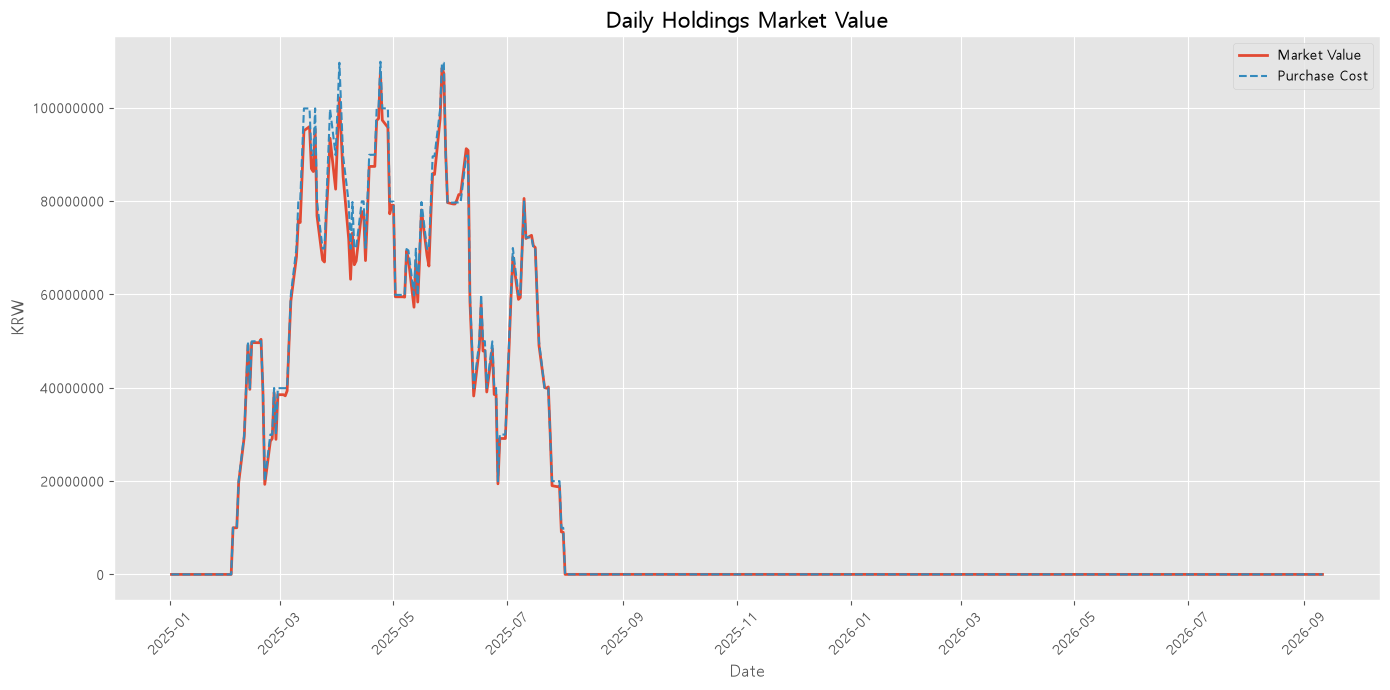

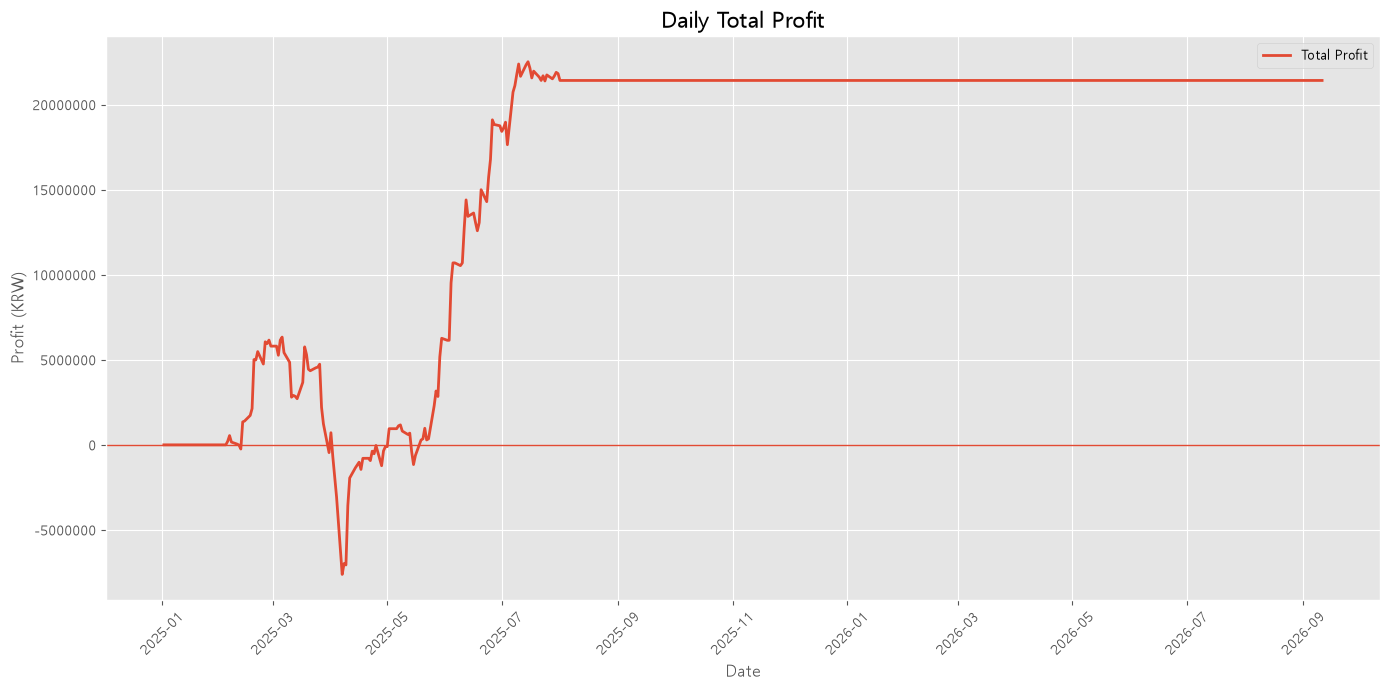

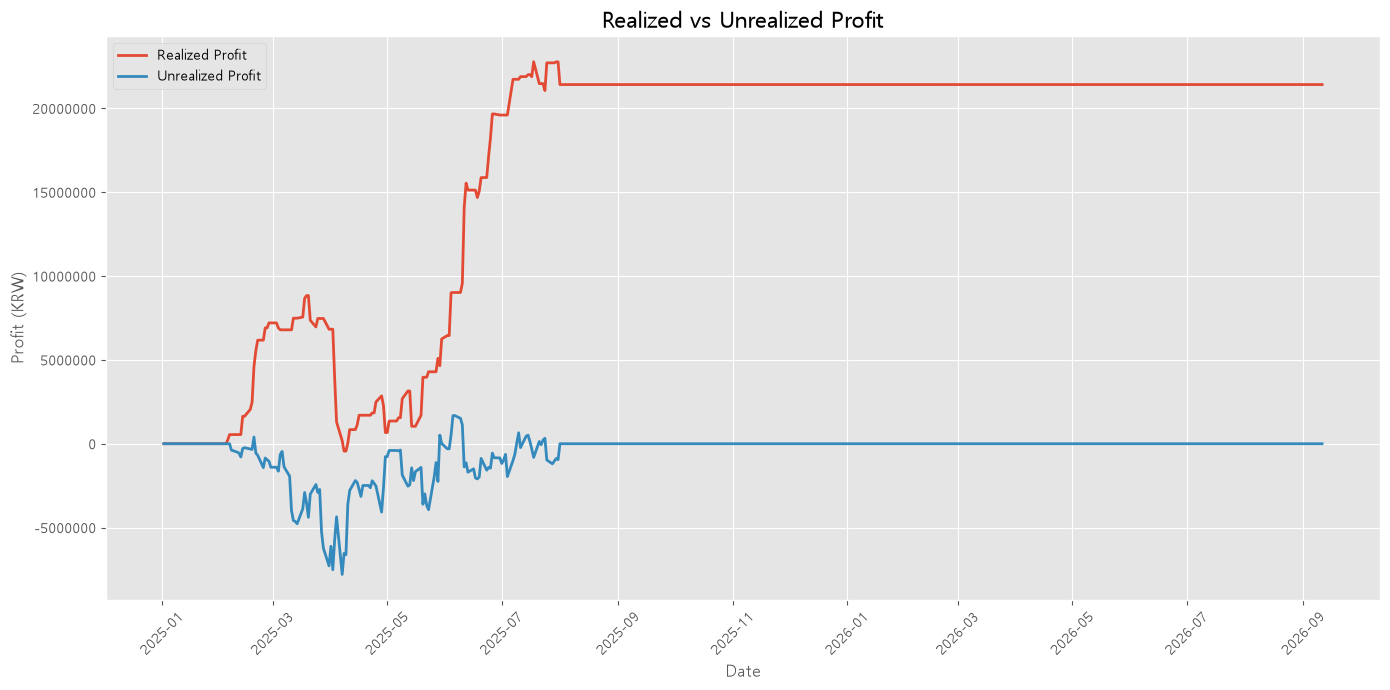

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Backtest Parameters
# ============================================================

BACKTEST_START = pd.Timestamp("2025-01-02")
BACKTEST_END = pd.Timestamp("2026-09-12")

UNIT_INVESTMENT = 10_000_000
MAX_INVESTMENT = 1_000_000_000

BACKTEST_SHORT_WINDOW = 5
BACKTEST_LONG_WINDOW = 20

UNIVERSE_SIZE = 500


# ============================================================
# 2. Universe
# ============================================================

universe = (
    fdr.StockListing("KRX")[["Code", "Name", "Market", "Marcap"]]
    .dropna()
)

universe = (
    universe
    .sort_values("Marcap", ascending=False)
    .head(UNIVERSE_SIZE)
    .reset_index(drop=True)
)


# ============================================================
# 3. Historical Price
# ============================================================

def load_backtest_history(stock_code):

    history = fdr.DataReader(
        stock_code,
        "20250101",
        BACKTEST_END.strftime("%Y%m%d")
    ).reset_index()

    return history.rename(
        columns={
            "Date": "일자",
            "Open": "시가",
            "High": "고가",
            "Low": "저가",
            "Close": "종가",
            "Volume": "거래량",
        }
    )


# ============================================================
# 4. Technical Indicators
# ============================================================

def prepare_history(stock_code):

    try:

        history = load_backtest_history(stock_code)

        if len(history) < BACKTEST_LONG_WINDOW:
            return stock_code, None

        analysis = analyze_technical_indicators(
            history,
            BACKTEST_SHORT_WINDOW,
            BACKTEST_LONG_WINDOW
        )

        analysis["단기선기울기"] = (
            analysis["단기이동평균"].pct_change(5)
        )

        return stock_code, analysis

    except Exception:

        return stock_code, None


# ============================================================
# 5. Parallel Loading
# ============================================================

indicator_histories = {}

with ThreadPoolExecutor(max_workers=8) as executor:

    futures = [
        executor.submit(
            prepare_history,
            code
        )
        for code in universe["Code"]
    ]

    for future in as_completed(futures):

        code, analysis = future.result()

        if analysis is not None:
            indicator_histories[code] = analysis


# ============================================================
# 6. Signal Score
# ============================================================

def calculate_signal_score(row):

    if (
        pd.isna(row["단기이동평균"])
        or pd.isna(row["장기이동평균"])
    ):
        return float("-inf")

    gap = (
        row["단기이동평균"]
        - row["장기이동평균"]
    ) / row["장기이동평균"]

    slope = (
        row["단기선기울기"]
        if pd.notna(row["단기선기울기"])
        else 0
    )

    score = (
        max(
            0,
            100 - abs(gap) * 1400
        )
        +
        max(
            0,
            min(
                30,
                slope * 1500
            )
        )
    )

    if row["강한신호"] == "강한 매수":
        score += 25

    return score


# ============================================================
# 7. Portfolio Variables
# ============================================================

holdings = {}

trade_log = []

cash = 0.0

total_purchased = 0.0


# ============================================================
# 매도로 인한 누적 실현손익
# ============================================================

total_realized_profit = 0.0


# ============================================================
# 추가
# 일별 포트폴리오 평가내역
# ============================================================

daily_portfolio_log = []


# ============================================================
# 8. Trading Dates
# ============================================================

trading_dates = pd.date_range(
    BACKTEST_START,
    BACKTEST_END,
    freq="B"
)


# ============================================================
# 9. Backtest
# ============================================================

for trading_date in trading_dates:

    buy_candidates = []


    # ========================================================
    # A. 종목별 매수/매도 판단
    # ========================================================

    for code, analysis in indicator_histories.items():

        rows = analysis[
            analysis["일자"] == trading_date
        ]

        if rows.empty:
            continue

        row = rows.iloc[-1]


        # ====================================================
        # A-1. 매도
        # 기존 조건 그대로
        # ====================================================

        if (
            code in holdings
            and row["매도신호수"] >= 3
        ):

            holding = holdings.pop(code)


            sale_amount = (
                holding["quantity"]
                * float(row["종가"])
            )


            # ------------------------------------------------
            # 매입원가
            # ------------------------------------------------

            purchase_cost = (
                holding["cost"]
            )


            # ------------------------------------------------
            # 실현손익
            # ------------------------------------------------

            realized_profit = (
                sale_amount
                - purchase_cost
            )


            # ------------------------------------------------
            # 누적 실현손익
            # ------------------------------------------------

            total_realized_profit += (
                realized_profit
            )


            cash += sale_amount


            trade_log.append(
                {
                    "일자": trading_date,

                    "구분": "매도",

                    "종목코드": code,

                    "종목명": holding[
                        "name"
                    ],

                    "수량": holding[
                        "quantity"
                    ],

                    "가격": float(
                        row["종가"]
                    ),

                    "금액": sale_amount,

                    "매입원가": (
                        purchase_cost
                    ),

                    "실현손익": (
                        realized_profit
                    ),

                    "사유": (
                        "매도조건수 2개 이상"
                    ),
                }
            )


        # ====================================================
        # A-2. 매수 후보
        # 기존 조건 그대로
        # ====================================================

        if (
            row["강한신호"]
            == "강한 매수"
        ):

            buy_candidates.append(
                (
                    calculate_signal_score(
                        row
                    ),
                    code,
                    row
                )
            )


    # ========================================================
    # B. 매수
    # 기존 조건 그대로
    # ========================================================

    if (
        total_purchased < MAX_INVESTMENT
        and buy_candidates
    ):

        score, code, row = max(
            buy_candidates,
            key=lambda item: item[0]
        )


        buy_budget = min(
            UNIT_INVESTMENT,
            MAX_INVESTMENT
            - total_purchased
        )


        close_price = float(
            row["종가"]
        )


        quantity = int(
            buy_budget
            // close_price
        )


        if quantity > 0:

            purchase_amount = (
                quantity
                * close_price
            )


            name = universe.loc[
                universe["Code"]
                == code,
                "Name"
            ].iloc[0]


            holding = (
                holdings.setdefault(
                    code,
                    {
                        "name": name,
                        "quantity": 0,
                        "cost": 0.0
                    }
                )
            )


            holding["quantity"] += (
                quantity
            )


            holding["cost"] += (
                purchase_amount
            )


            total_purchased += (
                purchase_amount
            )


            trade_log.append(
                {
                    "일자": trading_date,

                    "구분": "매수",

                    "종목코드": code,

                    "종목명": name,

                    "수량": quantity,

                    "가격": close_price,

                    "금액": purchase_amount,

                    "사유": (
                        "강한 매수 신호 최고점수"
                    ),
                }
            )


    # ========================================================
    # C. 추가
    # 당일 보유 종목 평가
    # ========================================================

    daily_holdings_value = 0.0
    daily_holdings_cost = 0.0

    valid_price_count = 0


    for holding_code, holding in holdings.items():

        holding_analysis = (
            indicator_histories[
                holding_code
            ]
        )


        # ----------------------------------------------------
        # 당일까지 존재하는 가장 최근 종가
        # ----------------------------------------------------

        holding_rows = holding_analysis[
            holding_analysis["일자"]
            <= trading_date
        ]


        if holding_rows.empty:
            continue


        latest_row = (
            holding_rows.iloc[-1]
        )


        latest_price = float(
            latest_row["종가"]
        )


        # ----------------------------------------------------
        # 해당 종목 평가금액
        # ----------------------------------------------------

        stock_market_value = (
            holding["quantity"]
            * latest_price
        )


        daily_holdings_value += (
            stock_market_value
        )


        daily_holdings_cost += (
            holding["cost"]
        )


        valid_price_count += 1


    # ========================================================
    # 보유종목 평가손익
    # ========================================================

    daily_unrealized_profit = (
        daily_holdings_value
        - daily_holdings_cost
    )


    # ========================================================
    # 실현손익 + 평가손익
    # ========================================================

    daily_total_profit = (
        total_realized_profit
        + daily_unrealized_profit
    )


    # ========================================================
    # 일별 결과 저장
    # ========================================================

    daily_portfolio_log.append(
        {
            "일자": trading_date,

            "보유종목수": len(
                holdings
            ),

            "보유종목매입원가": (
                daily_holdings_cost
            ),

            "보유종목평가금액": (
                daily_holdings_value
            ),

            "평가손익": (
                daily_unrealized_profit
            ),

            "누적실현손익": (
                total_realized_profit
            ),

            "총손익": (
                daily_total_profit
            ),
        }
    )


# ============================================================
# 10. Final Holdings
# ============================================================

final_holdings = []

final_value = cash


# ============================================================
# 최종 보유종목 평가손익
# ============================================================

total_unrealized_profit = 0.0


for code, holding in holdings.items():

    analysis = indicator_histories[
        code
    ]


    rows = analysis[
        analysis["일자"]
        <= BACKTEST_END
    ]


    final_price = float(
        rows.iloc[-1]["종가"]
    )


    market_value = (
        holding["quantity"]
        * final_price
    )


    final_value += (
        market_value
    )


    # ========================================================
    # 평가손익
    # ========================================================

    unrealized_profit = (
        market_value
        - holding["cost"]
    )


    total_unrealized_profit += (
        unrealized_profit
    )


    final_holdings.append(
        {
            "종목코드": code,

            "종목명": holding[
                "name"
            ],

            "수량": holding[
                "quantity"
            ],

            "평균매수가": (
                holding["cost"]
                / holding["quantity"]
            ),

            "최종가격": (
                final_price
            ),

            "매입원가": (
                holding["cost"]
            ),

            "평가금액": (
                market_value
            ),

            "평가손익": (
                unrealized_profit
            ),

            "평가수익률": (
                unrealized_profit
                / holding["cost"]
                if holding["cost"] > 0
                else 0
            ),
        }
    )


# ============================================================
# 11. DataFrame Conversion
# ============================================================

trade_log = pd.DataFrame(
    trade_log
)

final_holdings = pd.DataFrame(
    final_holdings
)

daily_portfolio = pd.DataFrame(
    daily_portfolio_log
)


# ============================================================
# 12. Final Profit
# ============================================================

final_profit = (
    total_realized_profit
    + total_unrealized_profit
)


return_rate = (
    final_profit
    / total_purchased
    if total_purchased
    else 0
)


# ============================================================
# 13. Backtest Summary
# ============================================================

backtest_summary = pd.Series(
    {
        "총 매수원금": (
            total_purchased
        ),

        "총 매도 실현손익": (
            total_realized_profit
        ),

        "최종 보유종목 평가손익": (
            total_unrealized_profit
        ),

        "최종 수익금": (
            final_profit
        ),

        "투자수익률": (
            return_rate
        ),

        "최종 평가금액": (
            final_value
        ),

        "현금잔액": (
            cash
        ),

        "매수 횟수": (
            int(
                (
                    trade_log["구분"]
                    == "매수"
                ).sum()
            )
            if not trade_log.empty
            else 0
        ),

        "매도 횟수": (
            int(
                (
                    trade_log["구분"]
                    == "매도"
                ).sum()
            )
            if not trade_log.empty
            else 0
        ),
    }
)


# ============================================================
# 14. Result
# ============================================================

print("=" * 90)
print("BACKTEST SUMMARY")
print("=" * 90)

display(
    backtest_summary.to_frame(
        "값"
    )
)


print()
print("=" * 90)
print("FINAL HOLDINGS")
print("=" * 90)

display(
    final_holdings
)


print()
print("=" * 90)
print("TRADE LOG")
print("=" * 90)

display(
    trade_log
)


print()
print("=" * 90)
print("DAILY PORTFOLIO VALUATION")
print("=" * 90)

display(
    daily_portfolio
)


# ============================================================
# 15. Plot
# ggplot2 Style
# ============================================================

plt.style.use("ggplot")


# ============================================================
# Graph 1
# 일별 보유종목 평가금액
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 7)
)


ax.plot(
    daily_portfolio["일자"],
    daily_portfolio["보유종목평가금액"],
    linewidth=2,
    label="Market Value"
)


ax.plot(
    daily_portfolio["일자"],
    daily_portfolio["보유종목매입원가"],
    linewidth=1.5,
    linestyle="--",
    label="Purchase Cost"
)


ax.set_title(
    "Daily Holdings Market Value",
    fontsize=16
)

ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "KRW"
)


ax.legend()


ax.ticklabel_format(
    style="plain",
    axis="y"
)


plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


# ============================================================
# Graph 2
# 일별 총손익
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 7)
)


ax.plot(
    daily_portfolio["일자"],
    daily_portfolio["총손익"],
    linewidth=2,
    label="Total Profit"
)


ax.axhline(
    y=0,
    linewidth=1
)


ax.set_title(
    "Daily Total Profit",
    fontsize=16
)


ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "Profit (KRW)"
)


ax.legend()


ax.ticklabel_format(
    style="plain",
    axis="y"
)


plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


# ============================================================
# Graph 3
# 실현손익 vs 평가손익
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 7)
)


ax.plot(
    daily_portfolio["일자"],
    daily_portfolio["누적실현손익"],
    linewidth=2,
    label="Realized Profit"
)


ax.plot(
    daily_portfolio["일자"],
    daily_portfolio["평가손익"],
    linewidth=2,
    label="Unrealized Profit"
)


ax.set_title(
    "Realized vs Unrealized Profit",
    fontsize=16
)


ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "Profit (KRW)"
)


ax.legend()


ax.ticklabel_format(
    style="plain",
    axis="y"
)


plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

## 자동 매수/매도 실행 (팝업 확인 방식)

백테스트 신호를 실주문으로 연결하는 셀입니다. **자동으로 주문하지 않고** 팝업(노트북에서는 입력 프롬프트)으로 매수/매도 여부를 확인합니다.

- 매도: 보유잔고 중 `매도신호수>=3` → 팝업 확인 후에만 시장가 매도
- 매수: **정규시장 시간(평일 09:00~15:30 KST)에만**, 강한 매수 중 점수 1등 1종목 → **정규시장 현시간가(실시간 현재가)** 로 지정가 매수 제안 → 팝업 확인 후에만 주문
- 장외 시간에는 매수를 스킵합니다.
- 기본 `dry_run=True`(제안만 기록), `LIVE_ORDER=True` + 팝업에서 `y` 입력 시에만 실주문(모의 기본)합니다.


In [ ]:
from zoneinfo import ZoneInfo
from datetime import datetime
from Function.KoreanStockTrading import KISOrderClient, append_trade_log
from Function.KoreanStockQuotes import KoreanStockQuoteClient
from pathlib import Path

# ===== 설정 =====
LIVE_ORDER = False  # True + 팝업 y 입력 시에만 실주문
IS_PAPER = True     # True=모의, False=실전
BUY_BUDGET = 1_000_000
AUTO_TRADE_LIVE = True

def is_market_open(now=None):
    now = now or datetime.now(ZoneInfo('Asia/Seoul'))
    return now.weekday() < 5 and (now.hour, now.minute) >= (9, 0) and (now.hour, now.minute) < (15, 30)

def live_price(code):
    try:
        qc = KoreanStockQuoteClient()
        qc.get_current_order_book(code)
        return float(qc.last_current_price) if qc.last_current_price is not None else None
    except Exception as e:
        print(f'현시간가 조회 실패 {code}: {e}')
        return None

def popup_ask(title, msg):
    try:
        import tkinter as tk
        from tkinter import messagebox
        r = tk.Tk(); r.withdraw(); r.attributes('-topmost', True)
        a = messagebox.askyesno(title, msg); r.destroy()
        return bool(a)
    except Exception:
        return input(f'[{title}] {msg} (y/N): ').strip().lower() in ('y','yes','예')

print('시장열림:', is_market_open())
print('LIVE_ORDER:', LIVE_ORDER, '| IS_PAPER:', IS_PAPER)


In [ ]:
# ===== 매도 제안: 매도신호수>=3 → 팝업 확인 후 시장가 매도 =====
order_client = KISOrderClient(is_paper=IS_PAPER)
log_path = project_root / 'Input' / 'auto_trade_log.csv'
try:
    bal = order_client.get_balance()
    display(bal.head())
except Exception as e:
    bal = None
    print(f'잔고조회 실패(키/계좌 확인 필요): {e}')

if bal is not None and not bal.empty:
    for _, b in bal.iterrows():
        code = str(b.get('pdno','')).strip()
        try:
            qty = int(float(str(b.get('hldg_qty',0) or 0)))
        except Exception:
            qty = 0
        if not code or qty <= 0:
            continue
        hist = fdr.DataReader(code, start_date, end_date).reset_index().rename(columns={'Date':'일자','Open':'시가','High':'고가','Low':'저가','Close':'종가','Volume':'거래량'})
        ana = analyze_technical_indicators(hist, 20, 60)
        latest = ana.dropna(subset=['단기이동평균','장기이동평균']).iloc[-1]
        n = int(latest['매도신호수'])
        print(f'{code} 매도신호수={n} 보유={qty}')
        if n >= 3:
            if popup_ask('매도 확인', f'[{code}] 매도신호 {n}개 → {qty}주 시장가 매도할까요?'):
                out = order_client.order_cash(code, qty, 0, side='sell', ord_dvsn='02', dry_run=not LIVE_ORDER)
                print(out)
            else:
                print('매도 스킵(팝업 거절)')


In [ ]:
# ===== 매수 제안: 정규장 시간에만 현시간가 지정가 =====
import pandas as pd
if not is_market_open():
    print('정규시장 시간 아님(평일 09:00~15:30) → 매수 스킵')
else:
    uni = fdr.StockListing('KRX')[['Code','Name','Market','Marcap']].dropna().sort_values('Marcap', ascending=False).head(100)
    rows = []
    for _, r in uni.iterrows():
        try:
            h = fdr.DataReader(r['Code'], start_date, end_date).reset_index().rename(columns={'Date':'일자','Open':'시가','High':'고가','Low':'저가','Close':'종가','Volume':'거래량'})
            a = analyze_technical_indicators(h, 20, 60)
            last = a.dropna(subset=['단기이동평균','장기이동평균']).iloc[-1]
            if last['강한신호'] == '강한 매수':
                gap = (last['단기이동평균']-last['장기이동평균'])/last['장기이동평균']
                score = max(0, 100-abs(gap)*1400) + 25
                rows.append((score, r['Code'], r['Name'], float(last['종가'])))
        except Exception:
            pass
    rows = sorted(rows, reverse=True)
    print(f'강한 매수 후보: {len(rows)}개')
    display(pd.DataFrame(rows, columns=['점수','코드','종목명','전일종가']).head())
    if rows:
        _, code, name, _ = rows[0]
        px = live_price(code)
        print(f'1등 {code} {name} 현시간가={px}')
        if px is None:
            print('현시간가 조회 실패 → 매수 스킵')
        else:
            qty = int(BUY_BUDGET // px)
            if qty > 0 and popup_ask('매수 확인', f'[{code} {name}] {px:,.0f}원 x {qty}주 지정가 매수할까요?'):
                print(order_client.order_cash(code, qty, int(px), side='buy', ord_dvsn='01', dry_run=not LIVE_ORDER))
            else:
                print('매수 스킵(팝업 거절 또는 수량 0)')
